# 13 — Model & Data Drift Monitoring (PSI)

The "is my model still OK?" notebook — run it monthly/quarterly. Compares a **baseline**
population (what the model was built on) against the **current** population and computes
the **Population Stability Index** for every feature and for the model score itself.

| PSI | Reading |
|---|---|
| < 0.10 | stable |
| 0.10 – 0.25 | moderate shift — investigate |
| > 0.25 | significant shift — likely retrain / revalidate |

**OUTPUT**: `outputs/monitoring_report.csv` + drift charts.

In [1]:
# ============================================================
# SETUP — run this cell first (no edits needed)
# ============================================================
# If any import fails, run in a notebook cell:
#   %pip install pandas numpy matplotlib seaborn scikit-learn sqlalchemy joblib openpyxl
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# All files this notebook produces are saved here:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print("Setup complete. Outputs will be saved to:", OUTPUT_DIR)

Setup complete. Outputs will be saved to: outputs


In [2]:
# ============================================================
# SAMPLE DATA GENERATOR (used only when DATA_SOURCE = "sample")
# ============================================================
# Creates a synthetic consumer-lending dataset so every cell below runs
# end-to-end even before you plug in your own data. Just run this cell.
def make_sample_lending_data(n=5000, seed=42):
    rng = np.random.default_rng(seed)
    fico = rng.normal(690, 55, n).clip(500, 850).round()
    dti = rng.normal(28, 10, n).clip(1, 65).round(1)
    loan_amount = rng.lognormal(9.4, 0.5, n).clip(1000, 50000).round(-2)
    income = rng.lognormal(11.1, 0.45, n).clip(15000, 400000).round(-2)
    utilization = rng.beta(2, 3, n).round(3) * 100
    tenure_months = rng.integers(0, 240, n)
    grade = rng.choice(list("ABCDE"), n, p=[0.25, 0.30, 0.25, 0.13, 0.07])
    purpose = rng.choice(["debt_consolidation", "credit_card", "home_improvement",
                          "auto", "medical", "other"], n,
                         p=[0.38, 0.22, 0.13, 0.12, 0.06, 0.09])
    state = rng.choice(["CA", "TX", "NY", "FL", "IL", "PA", "OH", "GA"], n)
    grade_rate = pd.Series(grade).map({"A": 7.5, "B": 10.5, "C": 13.5, "D": 17.0, "E": 21.0}).values
    interest_rate = (grade_rate - 0.010 * (fico - 690) + 0.02 * (dti - 28)
                     + rng.normal(0, 0.8, n)).clip(5, 30).round(2)
    origination_date = (pd.Timestamp("2023-01-01")
                        + pd.to_timedelta(rng.integers(0, 36, n) * 30, unit="D")).normalize()
    logit = (-4.2
             - 0.012 * (fico - 690)
             + 0.045 * (dti - 28)
             + 0.018 * (utilization - 40)
             + 0.35 * np.isin(grade, ["D", "E"]).astype(float)
             + 0.20 * (purpose == "debt_consolidation").astype(float))
    p_default = 1 / (1 + np.exp(-logit))
    default_flag = rng.binomial(1, p_default)
    df = pd.DataFrame({
        "loan_id": np.arange(1, n + 1),
        "origination_date": origination_date,
        "fico_score": fico, "dti": dti, "loan_amount": loan_amount,
        "annual_income": income, "revolving_utilization": utilization,
        "employment_tenure_months": tenure_months, "grade": grade,
        "loan_purpose": purpose, "state": state,
        "interest_rate": interest_rate, "default_flag": default_flag,
    })
    for col, frac in [("dti", 0.03), ("annual_income", 0.05), ("employment_tenure_months", 0.02)]:
        df.loc[df.sample(frac=frac, random_state=seed).index, col] = np.nan
    return df

print("Sample data generator defined.")

Sample data generator defined.


## INPUT — two datasets, same columns

- **`baseline_df`** — development/training-period data
- **`current_df`** — the latest scoring period

Load each from CSV/Excel/database exactly like the other notebooks
(`pd.read_csv`, `pd.read_sql`, ...). The sample branch simulates six months of
drift: FICO down, DTI and utilization up, product mix shifted.

In [3]:
# ============================================================
# INPUT — EDIT THIS CELL
# ============================================================
USE_SAMPLE = True    # <-- False when loading your own data below

if USE_SAMPLE:
    baseline_df = make_sample_lending_data(n=5000, seed=1)
    cur = make_sample_lending_data(n=5000, seed=99)
    # inject drift into the "current" period
    cur["fico_score"] = (cur["fico_score"] - 18).clip(500, 850)
    cur["dti"] = (cur["dti"] + 3).clip(1, 70)
    cur["revolving_utilization"] = (cur["revolving_utilization"] * 1.15).clip(0, 100)
    swap = cur.sample(frac=0.12, random_state=7).index
    cur.loc[swap, "loan_purpose"] = "debt_consolidation"
    current_df = cur
else:
    baseline_df = pd.read_csv("data/baseline_period.csv")     # <-- your baseline
    current_df = pd.read_csv("data/current_period.csv")       # <-- your latest period

TARGET_COL = "default_flag"   # or None if current labels aren't available yet
ID_COLS = ["loan_id"]
print(f"Baseline: {len(baseline_df):,} rows | Current: {len(current_df):,} rows")

Baseline: 5,000 rows | Current: 5,000 rows


In [4]:
# ============================================================
# PSI implementation (no edits needed)
# ============================================================
def psi(baseline, current, bins=10):
    """Population Stability Index between two samples of one variable."""
    baseline, current = pd.Series(baseline).dropna(), pd.Series(current).dropna()
    if pd.api.types.is_numeric_dtype(baseline) and baseline.nunique() > bins:
        edges = np.unique(np.quantile(baseline, np.linspace(0, 1, bins + 1)))
        edges[0], edges[-1] = -np.inf, np.inf
        b = pd.cut(baseline, edges).value_counts(normalize=True, sort=False)
        c = pd.cut(current, edges).value_counts(normalize=True, sort=False)
    else:
        cats = sorted(set(baseline.unique()) | set(current.unique()), key=str)
        b = baseline.value_counts(normalize=True).reindex(cats).fillna(0)
        c = current.value_counts(normalize=True).reindex(cats).fillna(0)
    b, c = b.clip(lower=1e-4), c.clip(lower=1e-4)   # avoid log(0)
    return float(((c - b) * np.log(c / b)).sum())

def psi_status(v):
    if v < 0.10: return "stable"
    if v < 0.25: return "MODERATE shift"
    return "SIGNIFICANT shift"
print("PSI functions defined.")

PSI functions defined.


,feature,psi,status
0,dti,0.0883,stable
1,revolving_utilization,0.0883,stable
2,fico_score,0.0861,stable
3,loan_purpose,0.0268,stable
4,annual_income,0.0067,stable
5,interest_rate,0.0047,stable
6,loan_amount,0.0033,stable
7,employment_tenure_months,0.0023,stable
8,grade,0.0021,stable
9,state,0.0015,stable


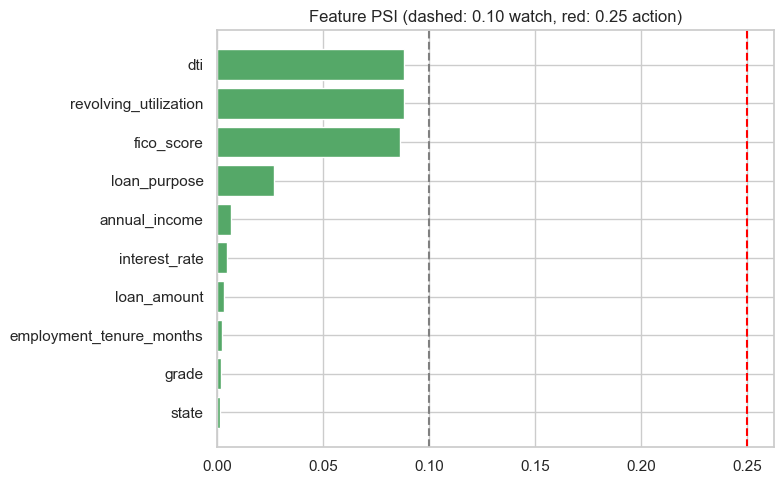

In [5]:
# ============================================================
# Feature drift — PSI for every shared column
# ============================================================
skip = set(ID_COLS + ([TARGET_COL] if TARGET_COL else []))
common = [c for c in baseline_df.columns
          if c in current_df.columns and c not in skip
          and not pd.api.types.is_datetime64_any_dtype(baseline_df[c])]

feature_psi = (pd.DataFrame([{"feature": c,
                              "psi": psi(baseline_df[c], current_df[c])} for c in common])
                 .sort_values("psi", ascending=False).reset_index(drop=True))
feature_psi["status"] = feature_psi["psi"].map(psi_status)
display(feature_psi)

fig, ax = plt.subplots(figsize=(8, 0.4 * len(feature_psi) + 1))
colors = feature_psi["status"].map({"stable": "#55A868", "MODERATE shift": "#DD8452",
                                    "SIGNIFICANT shift": "#C44E52"})
ax.barh(feature_psi["feature"][::-1], feature_psi["psi"][::-1], color=colors[::-1])
ax.axvline(0.10, ls="--", c="gray"); ax.axvline(0.25, ls="--", c="red")
ax.set_title("Feature PSI (dashed: 0.10 watch, red: 0.25 action)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "monitoring_feature_psi.png", dpi=150, bbox_inches="tight")
plt.show()

SCORE PSI: 0.1691  ->  MODERATE shift
AUC baseline: 0.7875   AUC current: 0.7104


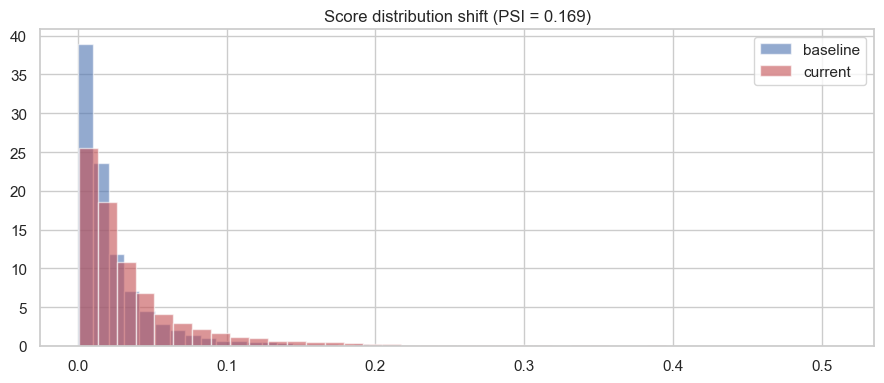

In [6]:
# ============================================================
# Score drift + performance — train on baseline, score both periods
# ============================================================
# If you already have a saved model, load it instead:
#   import joblib; model = joblib.load("outputs/best_model.joblib")
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def features_of(d):
    x = d.drop(columns=[c for c in skip if c in d.columns])
    num = x.select_dtypes(include=np.number).columns.tolist()
    cat = x.select_dtypes(include=["object", "category", "string"]).columns.tolist()
    return x[num + cat], num, cat

Xb, num_f, cat_f = features_of(baseline_df)
Xc_, _, _ = features_of(current_df)
Xc_ = Xc_[Xb.columns]

model = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), num_f),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_f)])),
    ("clf", LogisticRegression(max_iter=2000)),
])
model.fit(Xb, baseline_df[TARGET_COL])

score_b = model.predict_proba(Xb)[:, 1]
score_c = model.predict_proba(Xc_)[:, 1]
score_psi = psi(score_b, score_c)
print(f"SCORE PSI: {score_psi:.4f}  ->  {psi_status(score_psi)}")

perf = {}
if TARGET_COL and TARGET_COL in current_df.columns:
    perf["auc_baseline"] = roc_auc_score(baseline_df[TARGET_COL], score_b)
    perf["auc_current"] = roc_auc_score(current_df[TARGET_COL], score_c)
    print(f"AUC baseline: {perf['auc_baseline']:.4f}   AUC current: {perf['auc_current']:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(score_b, bins=40, alpha=0.6, density=True, label="baseline", color="#4C72B0")
ax.hist(score_c, bins=40, alpha=0.6, density=True, label="current", color="#C44E52")
ax.set_title(f"Score distribution shift (PSI = {score_psi:.3f})")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "monitoring_score_drift.png", dpi=150)
plt.show()

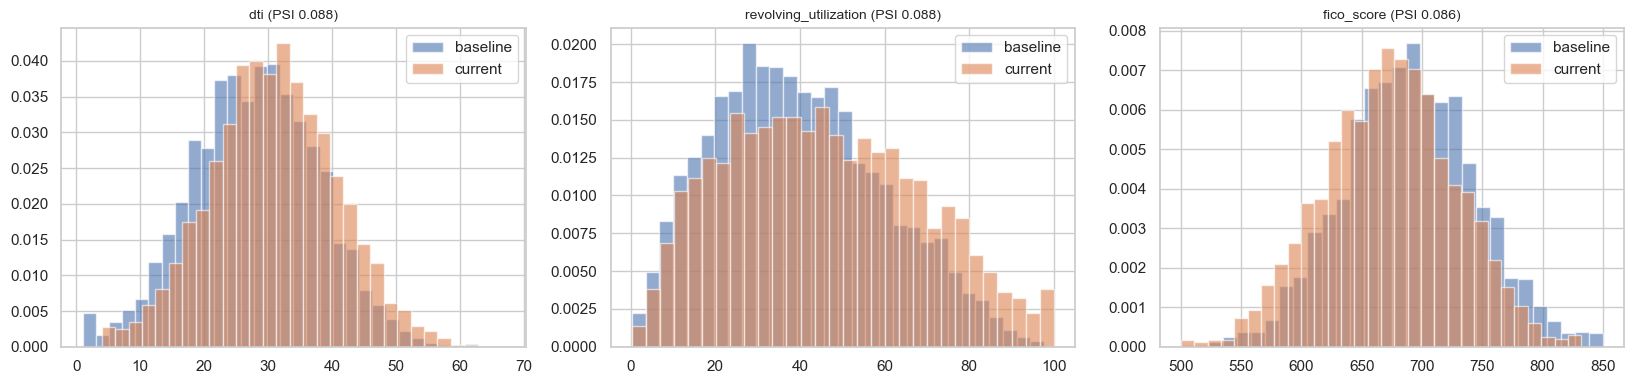

In [7]:
# ============================================================
# Where did the worst features move? Side-by-side distributions
# ============================================================
worst = feature_psi.head(3)["feature"].tolist()
fig, axes = plt.subplots(1, len(worst), figsize=(5.5 * len(worst), 4))
for ax, c in zip(np.atleast_1d(axes), worst):
    if pd.api.types.is_numeric_dtype(baseline_df[c]):
        ax.hist(baseline_df[c].dropna(), bins=30, alpha=0.6, density=True, label="baseline")
        ax.hist(current_df[c].dropna(), bins=30, alpha=0.6, density=True, label="current")
    else:
        w = pd.DataFrame({"baseline": baseline_df[c].value_counts(normalize=True),
                          "current": current_df[c].value_counts(normalize=True)})
        w.plot.bar(ax=ax)
    ax.set_title(f"{c} (PSI {feature_psi.set_index('feature').loc[c, 'psi']:.3f})", fontsize=10)
    ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "monitoring_top_drifted.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ============================================================
# OUTPUT — monitoring report
# ============================================================
report = feature_psi.copy()
report = pd.concat([report, pd.DataFrame([{"feature": "__MODEL_SCORE__",
                                           "psi": score_psi,
                                           "status": psi_status(score_psi)}])],
                   ignore_index=True)
for k, v in perf.items():
    report[k] = v
report["run_date"] = pd.Timestamp.now().normalize()
report.to_csv(OUTPUT_DIR / "monitoring_report.csv", index=False)

n_alert = (report["psi"] >= 0.25).sum()
print(f"Saved outputs/monitoring_report.csv — {n_alert} SIGNIFICANT shifts."
      + (" Investigate before trusting the model's output." if n_alert else ""))

Saved outputs/monitoring_report.csv — 0 SIGNIFICANT shifts.
